### Facial Recognition using PCA
Python notebooks cannot be run due to unavailable data.
#### Data Preprocessing
1. Grayscale conversion to reduce computational complexity
2. Image resizing and scaling to standardize facial dimensions
3. Brightness normalization
4. Rotation augmentation to improve robustness to tilted faces

#### Facial detection and recognition
5. Face detection using Haar Cascade classifiers with image scaling and rotation-based augmentation
6. PCA with n = 32 principal components to extract the most significant variance-based facial features
7. Experimental determination of an unknown-face classification threshold using feature-space distance metrics
8. Facial recognition performed on: 
    - still images
    - real-time video capture streams

In [ ]:
import cv2
import zipfile
import numpy as np
import os
import matplotlib.pyplot as plt
import random
from sklearn.preprocessing import StandardScaler
%matplotlib inline
from math import sin, cos, radians

In [2]:
#ALLOWS ROTATION
def face_detection(img):

    settings = {
      'scaleFactor': 1.3,  
      #In a group photo, there may be some faces which are near the camera than others. Naturally, such 
      #faces would appear more prominent than the ones behind. This factor compensates for that.
      'minNeighbors':4 , #4 
      # Parameter specifying how many neighbors each candidate rectangle should have to retain it.
      'minSize': (50, 50), #50x50
      'flags': cv2.CASCADE_SCALE_IMAGE
      }

    face = cv2.CascadeClassifier(cv2.data.haarcascades +"haarcascade_frontalface_alt2.xml")

    for angle in [0, -25, 25]:
        rimg = rotate_image(img, angle)
        detected = face.detectMultiScale(rimg, **settings)
        if len(detected):
            detected = [rotate_point(detected[-1], img, -angle)]
            break

  # Make a copy as we don't want to draw on the original image:
    for x, y, w, h in detected[-1:]:
        #cv2.rectangle(img, (x, y), (x+w, y+h), (255,0,0), 2)
        img = img[y:y+h, x:x+w]
        #cv2_imshow(img)
        #cv2.waitKey()

    return img

In [3]:
def rotate_image(image, angle):
    if angle == 0: return image
    height, width = image.shape[:2]
    rot_mat = cv2.getRotationMatrix2D((width/2, height/2), angle, 0.9)
    result = cv2.warpAffine(image, rot_mat, (width, height), flags=cv2.INTER_LINEAR)
    return result

def rotate_point(pos, img, angle):
    if angle == 0: return pos
    x = pos[0] - img.shape[1]*0.4
    y = pos[1] - img.shape[0]*0.4
    newx = x*cos(radians(angle)) + y*sin(radians(angle)) + img.shape[1]*0.4
    newy = -x*sin(radians(angle)) + y*cos(radians(angle)) + img.shape[0]*0.4
    return int(newx), int(newy), pos[2], pos[3]

In [4]:
folder = r'..\data\train'
img = cv2.imread(r'..\data\train\sanchari_4.jpg',0)
crop_faces = face_detection(img)
face = cv2.resize(crop_faces, (200,200))
cv2.imshow('pic', face)
cv2.waitKey(0)

-1

In [5]:
scl = StandardScaler()
faces = {}
dim = (300, 250) #height,width are from 100x100 to 300x250
#Reading images - 
folder = r'..\data\train'
c = 0
angle_list = [45, -45, 30, -30, 15, -15]
for filename in os.listdir(folder):
    img = cv2.imread(os.path.join(folder,filename),0) #reads as grayscale
  
    if img is not None:
        #Normalization is important in PCA since it is a variance maximizing exercise. 
        #It projects original data onto directions which maximize the variance
        img = face_detection(img)
        c = c + 1
        if c == 5:
            #Rotation augments
            num_rows, num_cols = img.shape[:2]
            rotation_degree = random.choice(angle_list)
            rotation_matrix = cv2.getRotationMatrix2D((num_rows/2,num_cols/2),rotation_degree,1)
            rotated_image = cv2.warpAffine(img,rotation_matrix,(num_rows,num_cols))
            aug_filename = filename.split('.')[0] + '_aug1.' + filename.split('.')[1]
            rotated_image = cv2.resize(rotated_image, dim)
            rotated_image = cv2.normalize(rotated_image, None, alpha=0,beta=10, norm_type=cv2.NORM_MINMAX)
            # convert from integers to floats
            rotated_image = rotated_image.astype('float32')
            # normalize to the range 0-1
            rotated_image /= 255.0
            faces[aug_filename] = rotated_image 
            c = 0
    
        img = cv2.resize(img, dim)
        #Normalization is important in PCA since it is a variance maximizing exercise. It projects your original data onto directions which maximize the variance
        img = cv2.normalize(img, None, alpha=0,beta=10, norm_type=cv2.NORM_MINMAX)
        # convert from integers to floats
        img = img.astype('float32')
        # normalize to the range 0-1
        img /= 255.0        
        faces[filename] = img
     

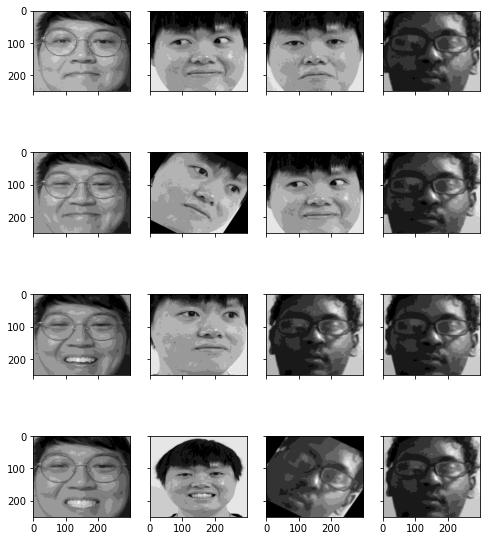

In [6]:
import matplotlib.pyplot as plt
 
fig, axes = plt.subplots(4,4,sharex=True,sharey=True,figsize=(8,10))
faceimages = list(faces.values())[-16:] # take last 16 images
for i in range(16):
    axes[i%4][i//4].imshow(faceimages[i], cmap="gray")
plt.show()

In [7]:
test_pic = 'devansh_4.jpeg'
# Take classes 1-39 for eigenfaces, keep entire class 40 and
# image 10 of class 39 as out-of-sample test
facematrix = []
facelabel = []
for key,val in faces.items():
    # if key.startswith("sanchari/"):
    #     continue # this is our test set, should identify as unknown
    if key == test_pic:
        continue # this is our test set, should identify as kavya
    facematrix.append(val.flatten())
    facelabel.append(key.split("_")[0])

#Create facematrix as (n_samples,n_pixels) matrix
facematrix = np.array(facematrix)

In [8]:
faceshape = list(faces.values())[0].shape
print("Face image shape:", faceshape)

Face image shape: (250, 300)


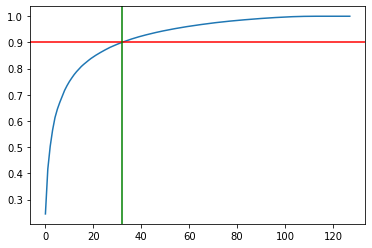

In [12]:
# Finding n_components
from sklearn.decomposition import PCA
pca = PCA().fit(facematrix) #n_components = 0.95
plt.plot(np.cumsum(pca.explained_variance_ratio_))
plt.axhline(y=0.90, color='r', linestyle='-')
plt.axvline(x=32, color='g', linestyle='-')
plt.show()
#print(pca.explained_variance_ratio_)

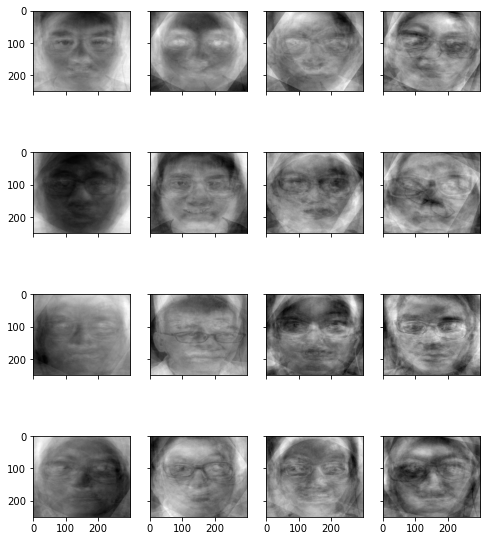

In [13]:
# Take the first K principal components as eigenfaces
pca = PCA(n_components = 32).fit(facematrix) #n_components = 0.95
n_components = 32
eigenfaces = pca.components_[:n_components]
 
# Show the first 16 eigenfaces
fig, axes = plt.subplots(4,4,sharex=True,sharey=True,figsize=(8,10))
for i in range(16):
    axes[i%4][i//4].imshow(eigenfaces[i].reshape(faceshape), cmap="gray")
plt.show()

In [12]:
# Generate weights as a KxN matrix where K is the number of eigenfaces and N the number of samples
weights = eigenfaces @ (facematrix - pca.mean_).T
# Roughly equivalent to:
# weights = []
# for i in range(facematrix.shape[0]):
#     weight = []
#     for j in range(n_components):
#         w = eigenfaces[j] @ (facematrix[i] - pca.mean_)
#         weight.append(w)
#     weights.append(weight)

54
Best match devansh with Euclidean distance 1.105451


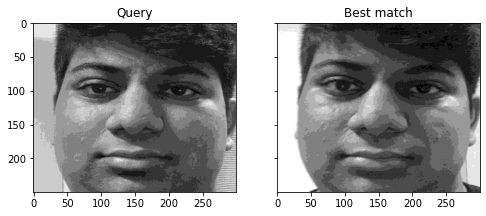

In [13]:
# Test on out-of-sample image of existing class
query = faces[test_pic].reshape(1,-1)
query_weight = eigenfaces @ (query - pca.mean_).T
print(len(query_weight))
euclidean_distance = np.linalg.norm(weights - query_weight, axis=0)
best_match = np.argmin(euclidean_distance)
print("Best match %s with Euclidean distance %f" % (facelabel[best_match], euclidean_distance[best_match]))
# Visualize
fig, axes = plt.subplots(1,2,sharex=True,sharey=True,figsize=(8,6))
axes[0].imshow(query.reshape(faceshape), cmap="gray")
axes[0].set_title("Query")
axes[1].imshow(facematrix[best_match].reshape(faceshape), cmap="gray")
axes[1].set_title("Best match")
plt.show()

In [14]:
#to get video on collab = https://colab.research.google.com/notebooks/snippets/advanced_outputs.ipynb#scrollTo=SucxddsPhOmj

# define a video capture object 
faceCascade=cv2.CascadeClassifier(cv2.data.haarcascades + "haarcascade_frontalface_alt2.xml")
vid = cv2.VideoCapture(0) 
if not vid.isOpened():
    print("Cannot open camera")
    exit()
# We need to set resolutions. So, convert them from float to integer.
frame_width = int(vid.get(3))
frame_height = int(vid.get(4))
size = (frame_width, frame_height)
# Below VideoWriter object will create a frame of above defined The output is stored in 'filename.avi' file.
result = cv2.VideoWriter('Face_recog.avi', 
                         cv2.VideoWriter_fourcc(*'MJPG'),
                         30, size)

while(True):
    # Capture the video frame by frame
    ret, frame = vid.read()
    
    if ret == True: 
        gray = cv2.cvtColor(frame, cv2.COLOR_BGR2GRAY)
        #For in plane rotation
        for angle in [0, -25, 25]:
            rimg = rotate_image(frame, angle)
            faces = faceCascade.detectMultiScale(
                    rimg,
                    scaleFactor=1.3, #1.1
                    minNeighbors=4,#4
                    minSize=(50, 50), #30x30
                    flags=cv2.CASCADE_SCALE_IMAGE
                )
            detected_arr = []
            if len(faces):
                for detected_face in faces:
                    det_face = [rotate_point(detected_face, frame, -angle)] #coordinates
                    detected_arr.append(det_face)
                break
        # Draw a rectangle around the faces
        for det_face in detected_arr:
            for (x, y, w, h) in det_face:
                #Image pre-processing
                img = gray[y:y+h, x:x+w]
                img = cv2.resize(img, dim)
                img = cv2.normalize(img, None, alpha=0,beta=10, norm_type=cv2.NORM_MINMAX)
                img = img.astype('float32')
                img /= 255.0

                #Running PCA
                query = img.reshape(1,-1)
                query_weight = eigenfaces @ (query - pca.mean_).T
                euclidean_distance = np.linalg.norm(weights - query_weight, axis=0)
                best_match = np.argmin(euclidean_distance)

                cv2.rectangle(frame, (x, y), (x+w, y+h), (0, 255, 0), 2)
                cv2.putText(frame, facelabel[best_match], (x, y-10), cv2.FONT_HERSHEY_SIMPLEX, 0.9, (36,255,12), 2)

        result.write(frame) #Write the frame into the file 'filename.avi' to save
        # Display the resulting frame 
        cv2.imshow('',frame) 
        
        if cv2.waitKey(1) & 0xFF == ord('s'):
            break
    else:
        break        
# After the loop release the cap object 
vid.release() 
result.release()
# Destroy all the windows 
cv2.destroyAllWindows() 
print("The video was successfully saved")

In [15]:
test_folder = r'..\data\test'
test_faces = {}
for filename in os.listdir(test_folder):
    img = cv2.imread(os.path.join(test_folder,filename),0) #reads as grayscale
  
    if img is not None:
        #print("hello")
        img = face_detection(img)
        img = cv2.resize(img, dim)
        #Normalization is important in PCA since it is a variance maximizing exercise. 
        #It projects your original data onto directions which maximize the variance
        img = cv2.normalize(img, None, alpha=0,beta=10, norm_type=cv2.NORM_MINMAX)
        # convert from integers to floats
        img = img.astype('float32')
        # normalize to the range 0-1
        img /= 255.0
        test_faces[filename] = img

54
Best match for aanchal_6.jpg is aanchal with Euclidean distance 0.308778
54
Best match for Aaron_6.jpg is Aaron with Euclidean distance 1.432886
54
Best match for Alex_6.jpg is Alex with Euclidean distance 0.537237
54
Best match for Amanda_6.jpg is Amanda with Euclidean distance 0.074923
54
Best match for Bob_6.jpg is Bob with Euclidean distance 0.963023
54
Best match for DarrylChing_6.jpg is DarrylChing with Euclidean distance 1.331342
54
Best match for devansh_6.jpeg is devansh with Euclidean distance 1.303083
54
Best match for DingHao_6.jpg is DingHao with Euclidean distance 1.196736
54
Best match for JiaLing_6.jpg is JiaLing with Euclidean distance 0.895486
54
Best match for JinTee_6.jpg is JinTee with Euclidean distance 0.966100
54
Best match for John_6.jpg is John with Euclidean distance 1.189175
54
Best match for KaiJie_6.jpg is Unknown with Euclidean distance 2.185055
54
Best match for kavya_6.jpeg is kavya with Euclidean distance 0.810434
54
Best match for KuanJuan_6.jpg is

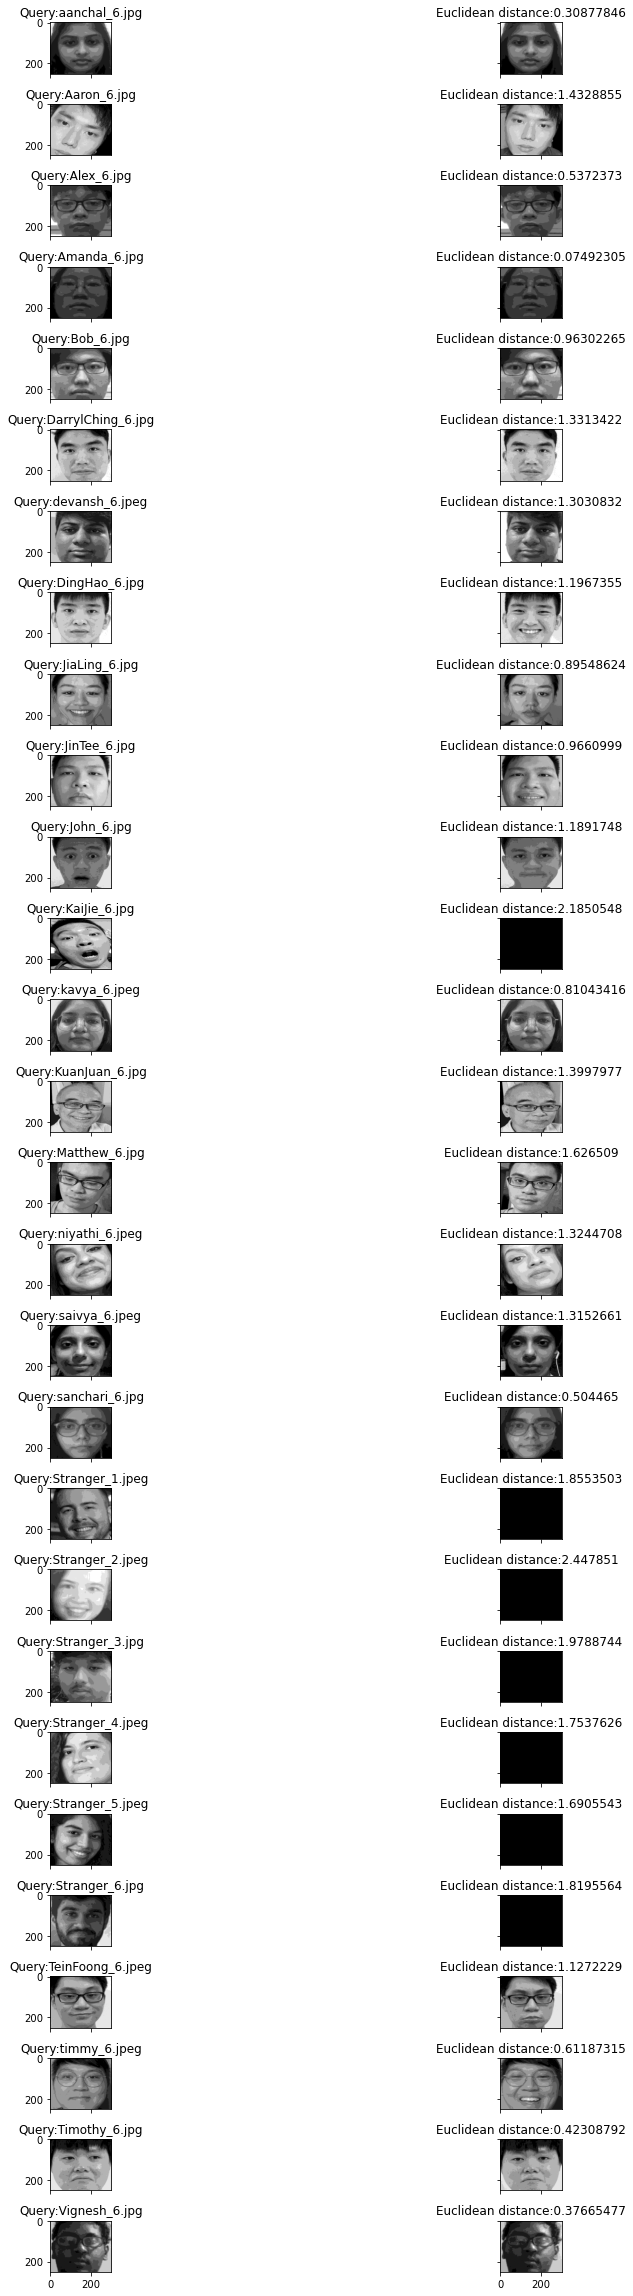

In [16]:
i = len(os.listdir(test_folder))
fig, axes = plt.subplots(i,2,sharex=True,sharey=True,figsize=(16,32))
count = 0
for filename in os.listdir(test_folder):
    img = cv2.imread(os.path.join(folder,filename),0) #reads as grayscale
    # Test on out-of-sample image of existing class
    query = test_faces[filename].reshape(1,-1)
    query_weight = eigenfaces @ (query - pca.mean_).T
    print(len(query_weight))
    euclidean_distance = np.linalg.norm(weights - query_weight, axis=0)
    best_match = np.argmin(euclidean_distance)
    #detecting unknown faces
    if euclidean_distance[best_match] > 1.65:
        facelabel[best_match] = "Unknown"
        facematrix[best_match] = 0
    
    print("Best match for %s is %s with Euclidean distance %f" % (filename, facelabel[best_match], euclidean_distance[best_match]))
    
    # Visualize
  
    axes[count, 0].imshow(query.reshape(faceshape), cmap="gray")
    axes[count, 0].set_title("Query:"+filename)
    axes[count, 1].imshow(facematrix[best_match].reshape(faceshape), cmap="gray")
    axes[count, 1].set_title("Euclidean distance:"+str(euclidean_distance[best_match]))
    count += 1

fig.tight_layout()
plt.show()